#  Frequency Distribution Concepts
    

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
#Loading dataset
df = pd.read_csv("Frequencydataset.csv")

print("Dataset Preview:")
print(df.head())

Dataset Preview:
   Student_ID  Scores  Hours_Studied
0           1      61              9
1           2      24              5
2           3      81              3
3           4      70              5
4           5      30              5


# 1. Frequency

In [12]:
# Count frequency of each score in ascending order

freq = df["Scores"].value_counts().sort_index()

print("\n Frequency \n", freq)


 Frequency 
 Scores
10    18
11    15
12    14
13    13
14    13
      ..
95    15
96    10
97     9
98    14
99    21
Name: count, Length: 90, dtype: int64


# 2. Frequency Distribution

In [16]:
#Group Series into ranges and count how many fall in each group

bins = [0,50,70,100] # define score ranges
labels = ["Low", "Medium", "High"] # names for each range

df["Score_Group"] = pd.cut(df["Scores"], bins=bins, labels=labels)

freq_dist = df["Score_Group"].value_counts().sort_index()
# value_counts(): counts values in each group
# sort_index(): keep order

print("\n Frequency Distribution \n", freq_dist)


 Frequency Distribution 
 Score_Group
Low       471
Medium    221
High      308
Name: count, dtype: int64


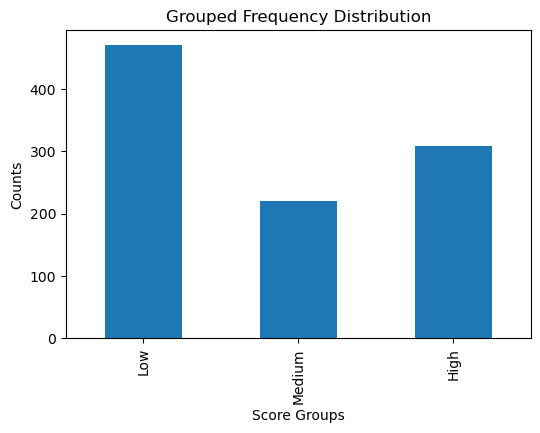

In [17]:
plt.figure(figsize=(6,4))
freq_dist.plot(kind = "bar")

plt.title("Grouped Frequency Distribution")
plt.xlabel("Score Groups")
plt.ylabel("Counts")
plt.show()

# 3. Relative Frequency

In [18]:
#Calculate proportion (percentage) of each score

rel_freq = freq / len(df)

print("\n Relative Frequency \n:", rel_freq)


 Relative Frequency 
: Scores
10    0.018
11    0.015
12    0.014
13    0.013
14    0.013
      ...  
95    0.015
96    0.010
97    0.009
98    0.014
99    0.021
Name: count, Length: 90, dtype: float64


# 4. Cumulative Frequency

In [19]:
#Calculates running total of frequencies
cum_freq = freq.cumsum()

#cumsum() : adds frequencies step-by-step

print("\nCumulative Frequency\n", cum_freq)


Cumulative Frequency
 Scores
10      18
11      33
12      47
13      60
14      73
      ... 
95     946
96     956
97     965
98     979
99    1000
Name: count, Length: 90, dtype: int64


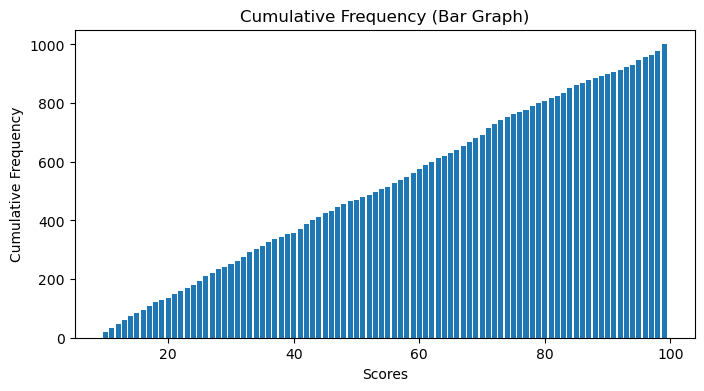

In [20]:
plt.figure(figsize=(8,4))

plt.bar(cum_freq.index, cum_freq.values)

plt.title("Cumulative Frequency (Bar Graph)")
plt.xlabel("Scores")
plt.ylabel("Cumulative Frequency")

plt.show()

# 5. Contigency Table

In [22]:
#Shows the relationship between score groups and study hours

cont_table = pd.crosstab(df["Score_Group"], df["Hours_Studied"])

print("\n Contingency Table \n:", cont_table)


 Contingency Table 
: Hours_Studied   1   2   3   4   5   6   7   8   9
Score_Group                                      
Low            59  54  53  49  57  43  45  58  53
Medium         26  27  20  20  27  22  33  23  23
High           33  37  33  33  27  42  33  34  36


Text(0, 0.5, 'Number of Students')

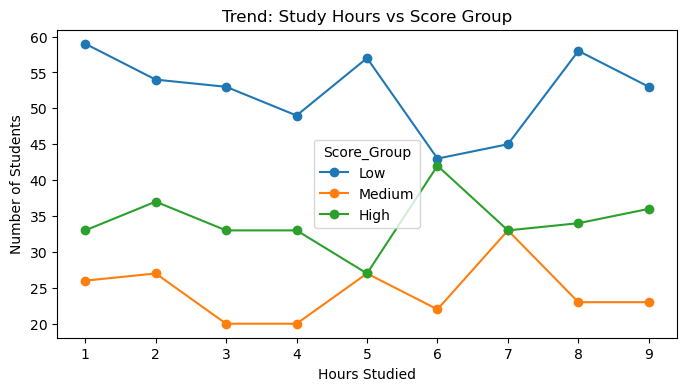

In [23]:
cont_table.T.plot(figsize=(8,4), marker = "o")
plt.title("Trend: Study Hours vs Score Group")
plt.xlabel("Hours Studied")
plt.ylabel("Number of Students")

# 6. Covariance

In [26]:
# Measures how scores and hours studied moves together

cov = df[["Scores", "Hours_Studied"]].cov().iloc[0,1]

print(f"Covariance between Scores and Hours_Studied: {cov:.2f}")


Covariance between Scores and Hours_Studied: 0.26


# 7. Correlation

In [28]:
# Strength of relationship (-1 to +1)

corr = df["Scores"].corr(df["Hours_Studied"])
print(f"Correlation: {corr:.2f} Relationship is very weak.")

Correlation: 0.00 Relationship is very weak.


# 8. Distribution

Text(0, 0.5, 'Density')

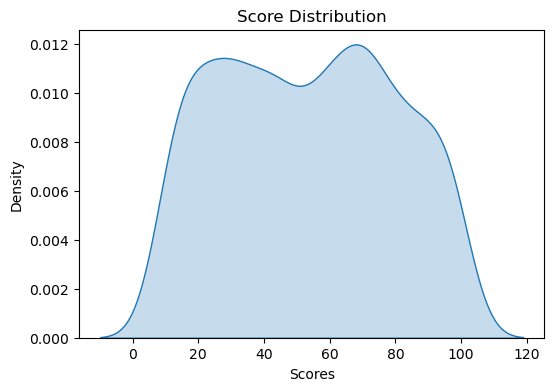

In [29]:
plt.figure(figsize=(6,4))

sns.kdeplot(x=df["Scores"], fill =True)
plt.title("Score Distribution")
plt.xlabel("Scores")
plt.ylabel("Density")

# 9. Types of Distribution

Normal, Uniform, Binomial, Poisson, and Exponential distributions

# 10. Central Limit Theorem 

Text(0, 0.5, 'Frequency')

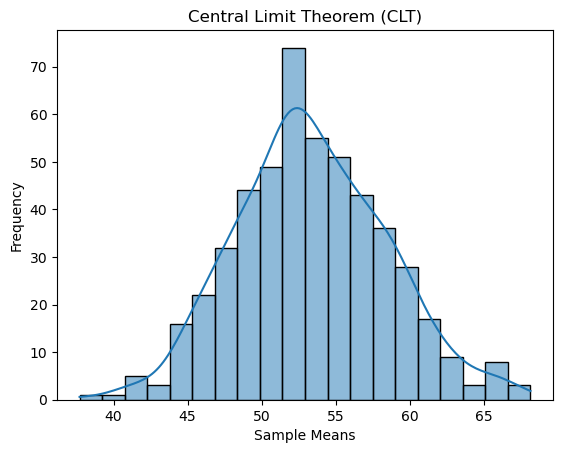

In [30]:
# Sampling means form normal distribution

means = [np.mean(np.random.choice(df["Scores"], 30)) for _ in range(500)]

sns.histplot(means, bins = 20, kde = True)
plt.title("Central Limit Theorem (CLT)")
plt.xlabel("Sample Means")
plt.ylabel("Frequency")